In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt



ModuleList()

In [3]:

# Simple MLP
class Net(nn.Module):
    def __init__(self, layers=[1, 50, 50, 50, 1]):  # input 1D, output 1D
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-2):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            self.layers.append(nn.Tanh())
        self.layers.append(nn.Linear(layers[-2], layers[-1]))
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Data: 500 points in [-pi, pi]
N = 500
x = torch.linspace(-np.pi, np.pi, N).reshape(-1, 1)
y = torch.sin(x)

x.requires_grad = True  # important for later PINNs!

model = Net()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training loop
epochs = 5000
for epoch in range(epochs):
    pred = model(x)
    loss = loss_fn(pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 0.398019
Epoch 1000, Loss: 0.000008
Epoch 2000, Loss: 0.000241
Epoch 3000, Loss: 0.000006
Epoch 4000, Loss: 0.000000


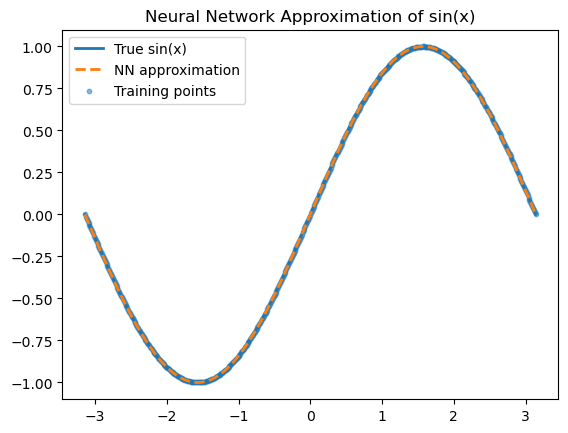

In [4]:

# Plot results
with torch.no_grad():
    x_test = torch.linspace(-np.pi, np.pi, 1000).reshape(-1, 1)
    y_pred = model(x_test)
    
    plt.plot(x_test.numpy(), np.sin(x_test.numpy()), label='True sin(x)', linewidth=2)
    plt.plot(x_test.numpy(), y_pred.numpy(), '--', label='NN approximation', linewidth=2)
    plt.scatter(x.numpy(), y.numpy(), s=10, alpha=0.5, label='Training points')
    plt.legend()
    plt.title('Neural Network Approximation of sin(x)')
    plt.show()